In [1]:
# ===== Libraries =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
df = pd.read_csv("diabetes.csv")

"Shape:", df.shape


('Shape:', (768, 9))

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 🔍 Hidden Missing Values in the Pima Diabetes Dataset

## The Problem
Some columns contain **zero values that are medically impossible**:
- You can't have a `Glucose` level of 0 and still be alive
- You can't have a `BMI` of 0
- You can't have a `BloodPressure` of 0

These zeros are **not real data** — they are missing values that were encoded as 0 instead of `NaN`.

## Affected Columns

| Column | Zero Count | % of Data |
|---|---|---|
| Glucose | 5 | 0.7% |
| BloodPressure | 35 | 4.6% |
| SkinThickness | 227 | 29.6% |
| Insulin | 374 | 48.7% |
| BMI | 11 | 1.4% |

## The Solution
Replace all 0 values in these columns with `NaN`, then fill them using the **median** of each column.

We use the **median** instead of the mean because:
- The median is more robust to outliers
- Medical data often has skewed distributions

In [6]:
# ===== Check Zeros (Hidden Missing Values) =====
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero values count per column:")
for col in cols_with_zeros:
    zero_count = (df[col] == 0).sum()
    pct = (zero_count / len(df)) * 100
    print(f"  {col}: {zero_count} zeros ({pct:.1f}%)")

Zero values count per column:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


In [ ]:
# ===== Handle Hidden Missing Values =====
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)



In [9]:
for col in cols_with_zeros:
    df[col].fillna(df[col].median(), inplace=True)



In [10]:
print("✅ Missing values handled!")
print("\nZero check after fix:")
for col in cols_with_zeros:
    print(f"  {col}: {(df[col] == 0).sum()} zeros remaining")

✅ Missing values handled!

Zero check after fix:
  Glucose: 0 zeros remaining
  BloodPressure: 0 zeros remaining
  SkinThickness: 0 zeros remaining
  Insulin: 0 zeros remaining
  BMI: 0 zeros remaining


Class Distribution:
  No Diabetes (0): 500 samples (65.1%)
  Diabetes    (1): 268 samples (34.9%)


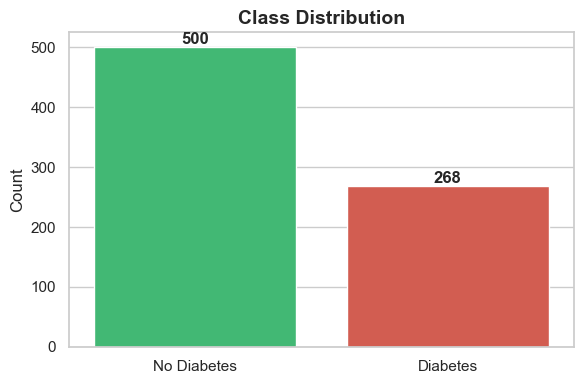

In [11]:
# ===== Check Class Distribution =====
counts = df['Outcome'].value_counts()
pct = df['Outcome'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  No Diabetes (0): {counts[0]} samples ({pct[0]:.1f}%)")
print(f"  Diabetes    (1): {counts[1]} samples ({pct[1]:.1f}%)")

# Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.xlabel('')
plt.ylabel('Count')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2, p.get_height()),
                       ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

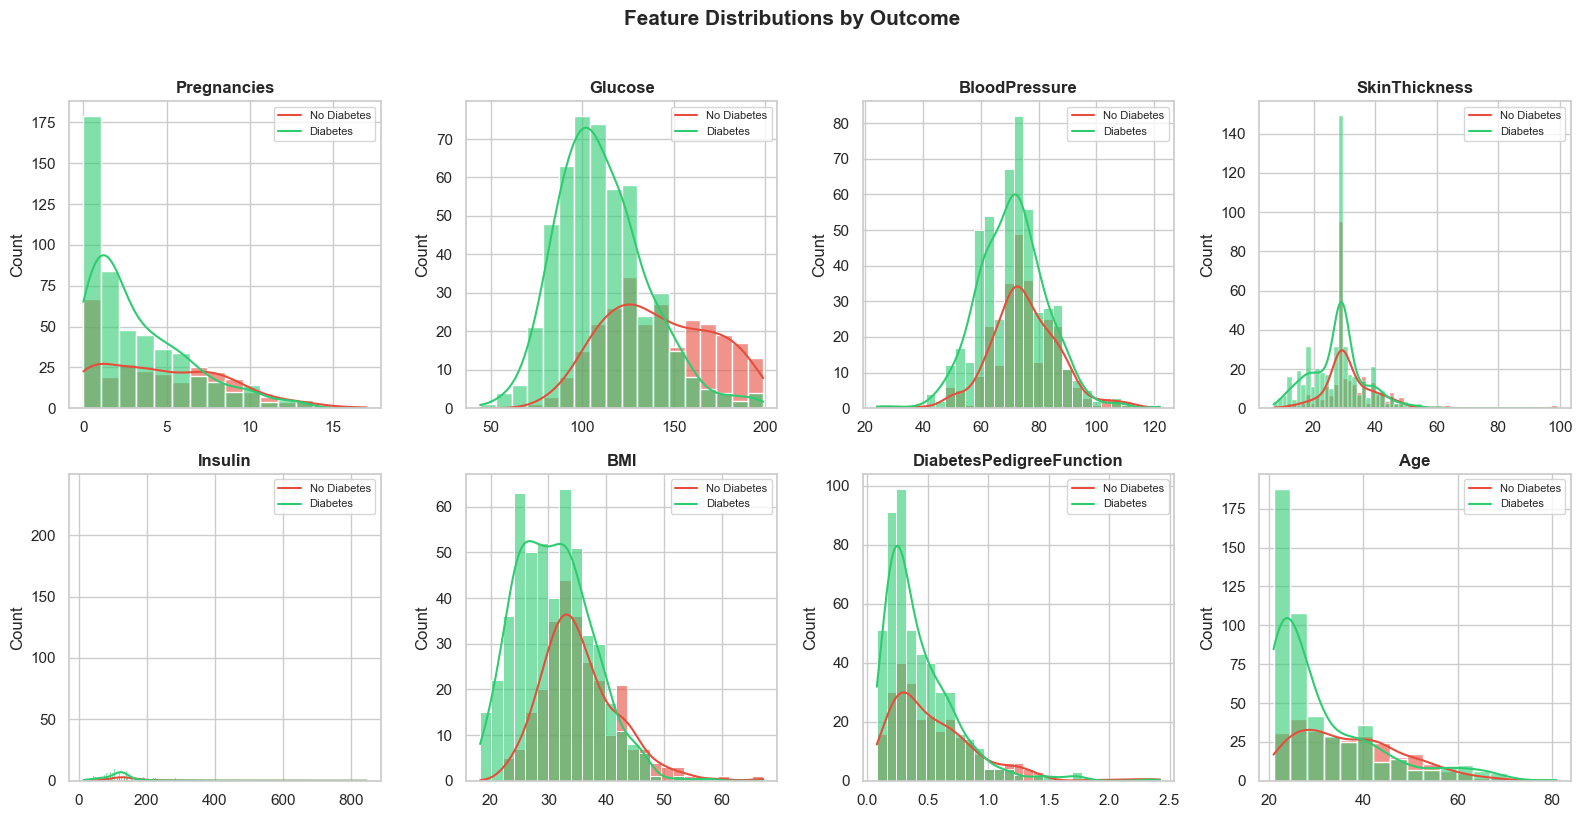

In [12]:
# ===== Feature Distributions =====
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True,
                 palette=['#2ecc71', '#e74c3c'], ax=axes[i], alpha=0.6)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['No Diabetes', 'Diabetes'], fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

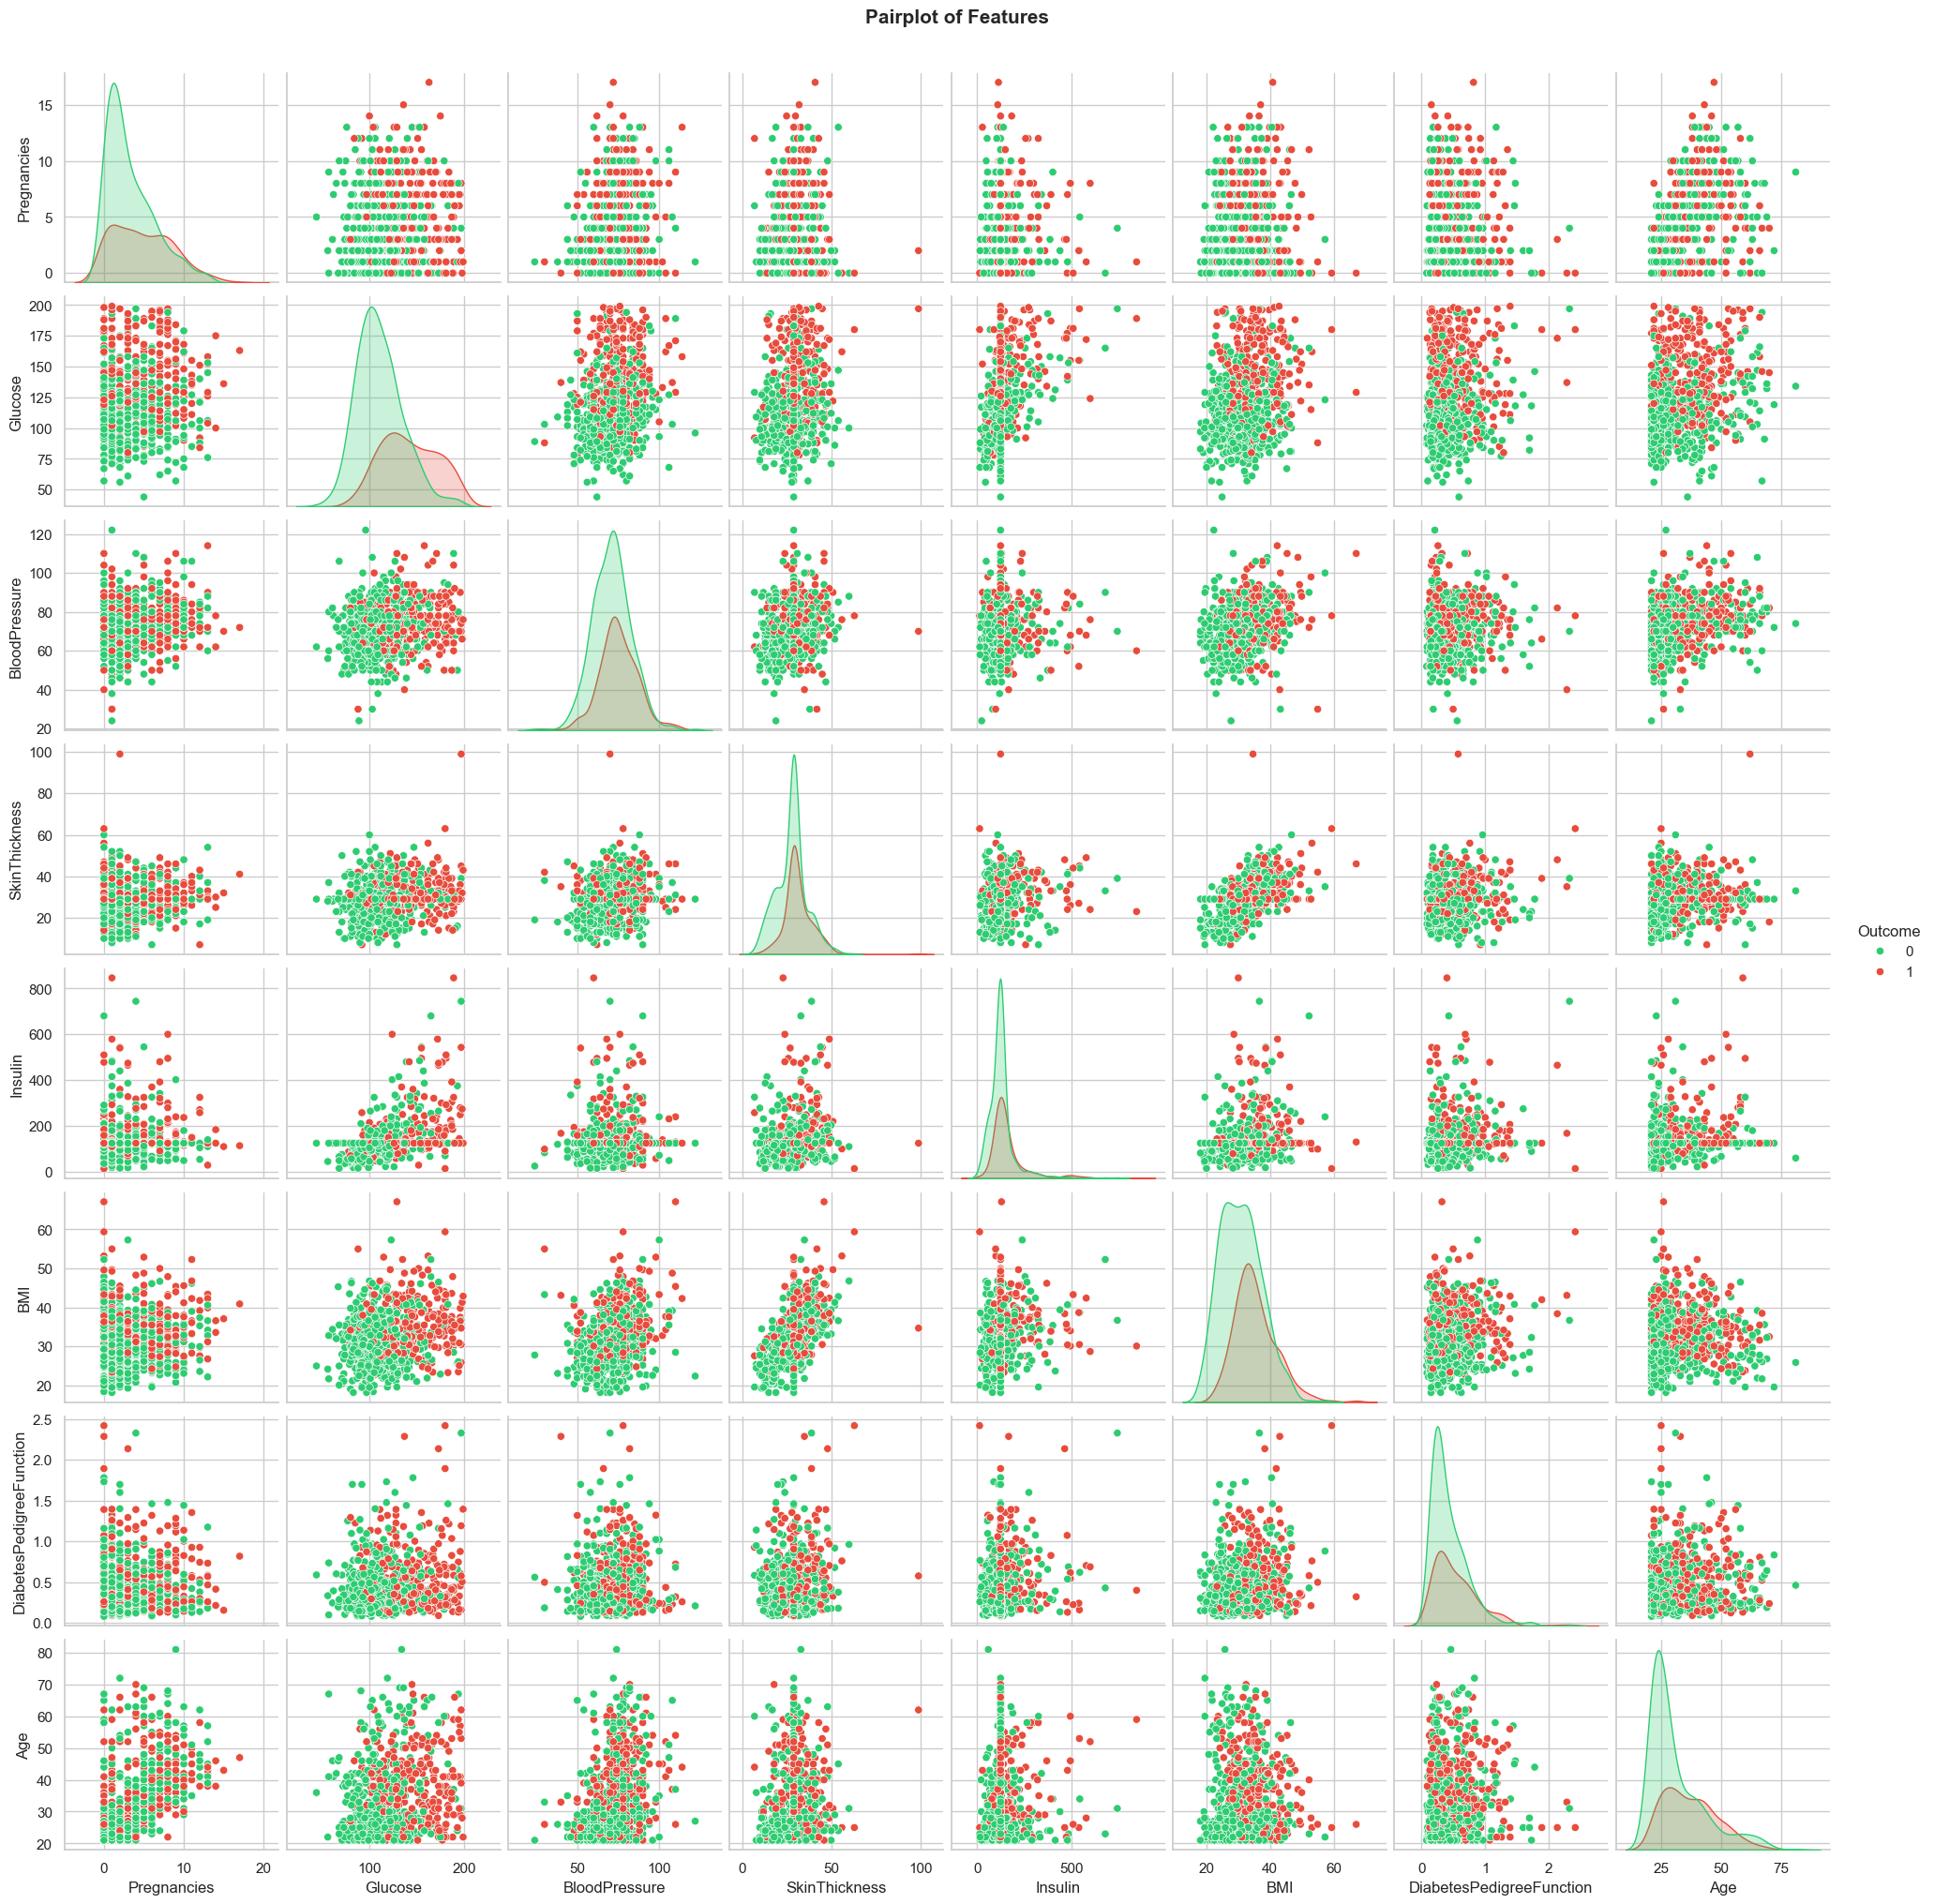

In [13]:
sns.pairplot(df, hue='Outcome', palette=['#2ecc71', '#e74c3c'], diag_kind='kde')
plt.suptitle('Pairplot of Features', fontsize=15, fontweight='bold', y=1.02)
plt.show()

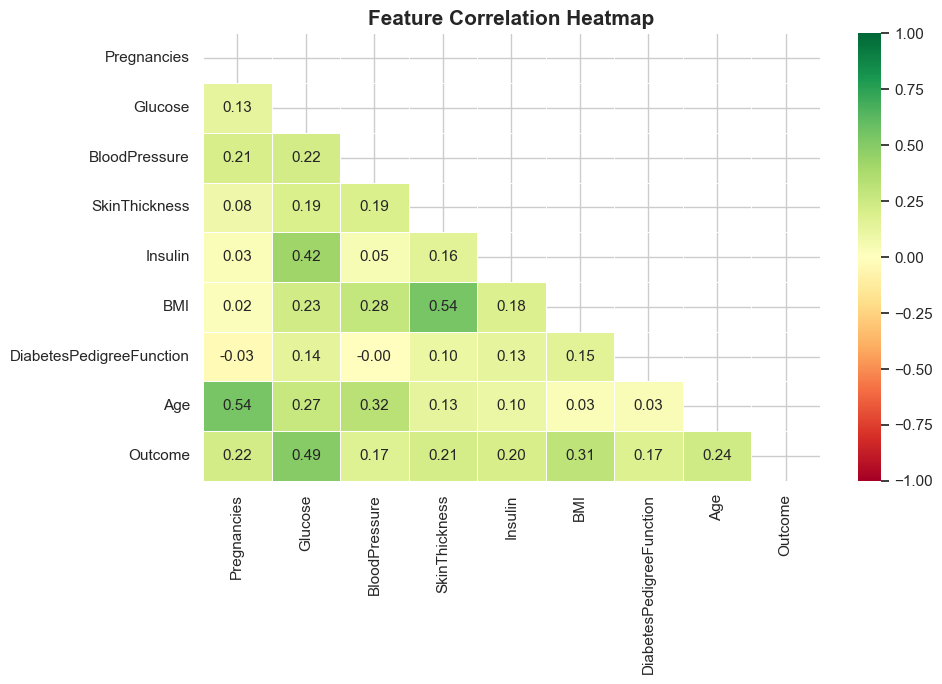

In [ ]:
# ===== Correlation Heatmap =====
plt.figure(figsize=(10, 7))

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))#الـ mask بتخلي الـ heatmap يظهر نص بس (المثلث التحتاني) عشان منكررش نفس المعلومة

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={"size": 11}, vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

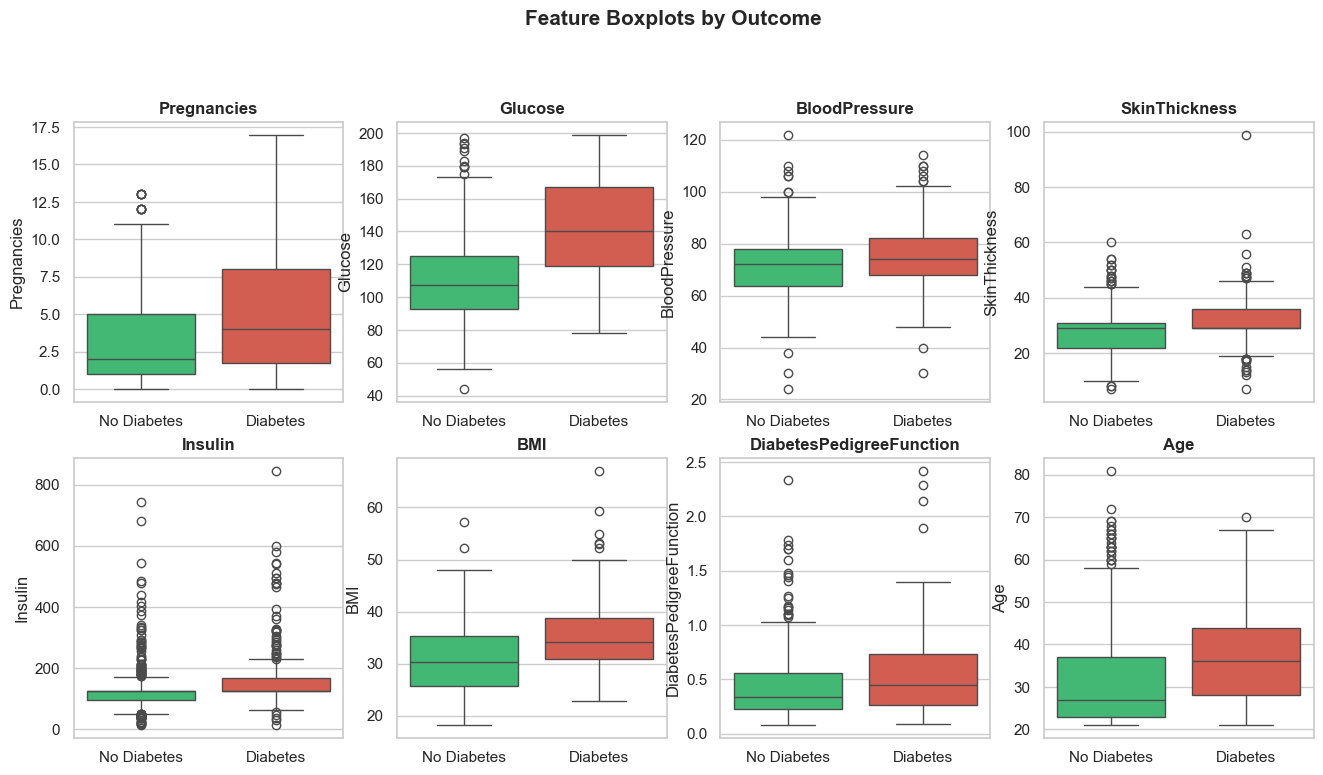

In [15]:
# ===== Boxplots =====
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Outcome', y=col,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.suptitle('Feature Boxplots by Outcome', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout

In [16]:
# ===== Feature Engineering & Scaling =====
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Features scaled successfully!")
print(f"\nX shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print("\nSample after scaling:")
X_scaled.head()

✅ Features scaled successfully!

X shape: (768, 8)
y shape: (768,)

Sample after scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


Before SMOTE:
  No Diabetes (0): 500
  Diabetes    (1): 268

After SMOTE:
  No Diabetes (0): 500
  Diabetes    (1): 500


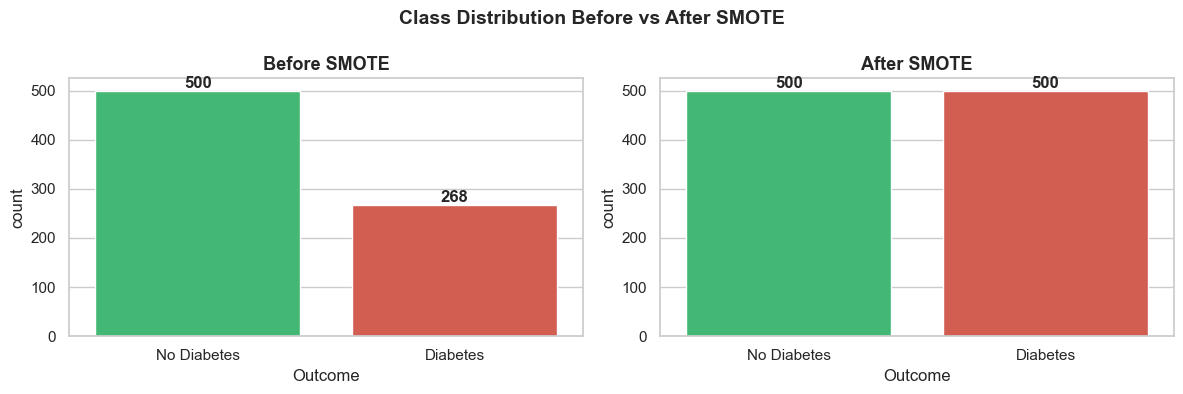

In [17]:

# ===== Handle Unbalanced Data with SMOTE =====
print("Before SMOTE:")
print(f"  No Diabetes (0): {(y == 0).sum()}")
print(f"  Diabetes    (1): {(y == 1).sum()}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nAfter SMOTE:")
print(f"  No Diabetes (0): {(y_resampled == 0).sum()}")
print(f"  Diabetes    (1): {(y_resampled == 1).sum()}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

sns.countplot(x=y_resampled, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ===== Cross Validation + Regularization =====
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression (No Reg)' : LogisticRegression(penalty=None, max_iter=1000),
    'Logistic Regression (L1)'     : LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000),
    'Logistic Regression (L2)'     : LogisticRegression(penalty='l2', C=1.0, max_iter=1000),
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_resampled, y_resampled,
                             cv=skf, scoring='roc_auc')
    results[name] = scores
    print(f"{name}")
    print(f"  AUC per fold: {scores.round(3)}")
    print(f"  Mean AUC: {scores.mean():.3f} ± {scores.std():.3f}\n")

Logistic Regression (No Reg)
  AUC per fold: [0.843 0.875 0.824 0.841 0.839]
  Mean AUC: 0.845 ± 0.017

Logistic Regression (L1)
  AUC per fold: [0.843 0.876 0.824 0.841 0.839]
  Mean AUC: 0.845 ± 0.017

Logistic Regression (L2)
  AUC per fold: [0.843 0.875 0.824 0.84  0.839]
  Mean AUC: 0.844 ± 0.017



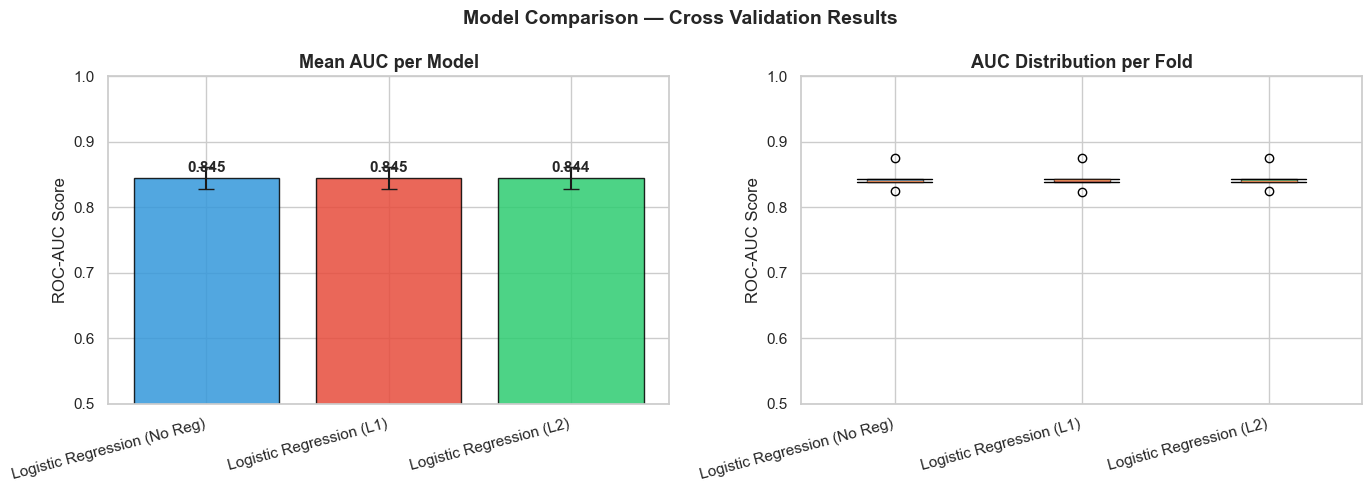

In [19]:
# ===== Compare Models Visualization =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot - Mean AUC
names = list(results.keys())
means = [results[m].mean() for m in names]
stds  = [results[m].std()  for m in names]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = axes[0].bar(names, means, yerr=stds, capsize=6,
                   color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Mean AUC per Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticklabels(names, rotation=15, ha='right')
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=11, fontweight='bold')

# Box plot - AUC distribution per fold
data_to_plot = [results[m] for m in names]
bp = axes[1].boxplot(data_to_plot, patch_artist=True, capwidths=0.4)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('AUC Distribution per Fold', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylim(0.5, 1.0)

plt.suptitle('Model Comparison — Cross Validation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

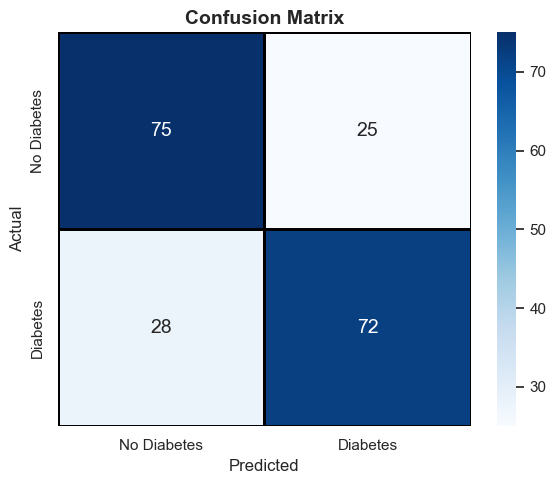


Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.73      0.75      0.74       100
    Diabetes       0.74      0.72      0.73       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200



In [20]:
# ===== Train Best Model & Confusion Matrix =====
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

best_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            linewidths=1, linecolor='black', annot_kws={"size": 14})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

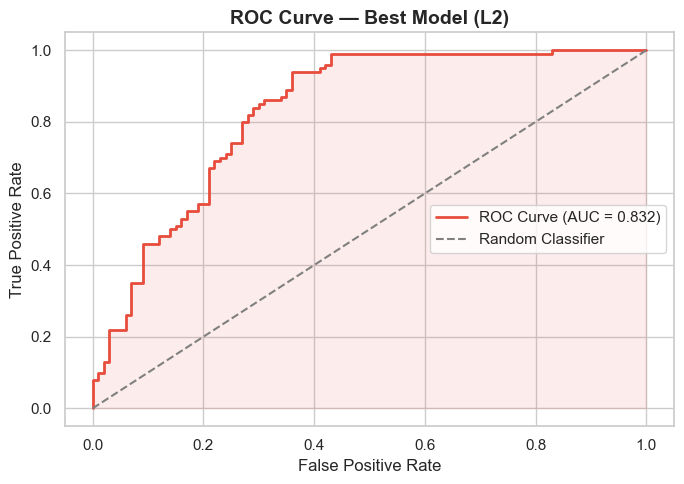

✅ Final AUC Score: 0.832


In [21]:
# ===== ROC Curve =====
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Best Model (L2)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"✅ Final AUC Score: {auc_score:.3f}")

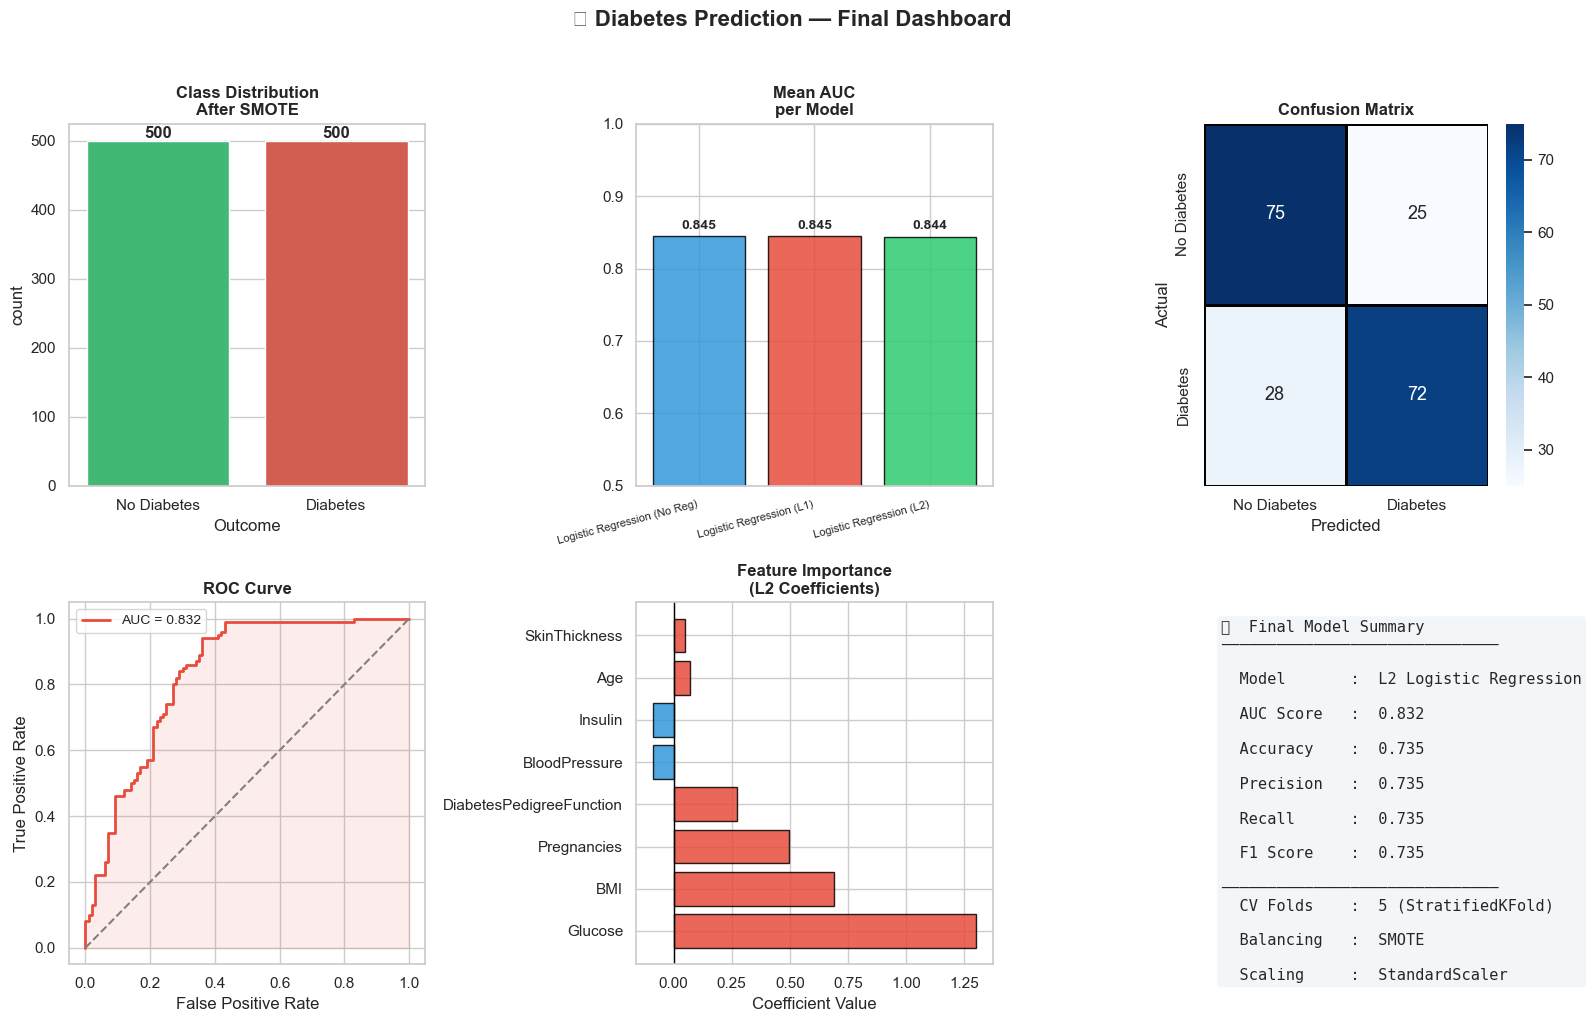

In [24]:
# ===== Final Summary Dashboard =====
importance = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig = plt.figure(figsize=(16, 10))

# 1. Class Distribution After SMOTE
ax1 = fig.add_subplot(2, 3, 1)
sns.countplot(x=y_resampled, palette=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title('Class Distribution\nAfter SMOTE', fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No Diabetes', 'Diabetes'])
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

# 2. Cross Validation AUC
ax2 = fig.add_subplot(2, 3, 2)
names  = list(results.keys())
means  = [results[m].mean() for m in names]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars   = ax2.bar(names, means, color=colors, alpha=0.85, edgecolor='black')
ax2.set_title('Mean AUC\nper Model', fontweight='bold')
ax2.set_ylim(0.5, 1.0)
ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')

# 3. Confusion Matrix
ax3 = fig.add_subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            linewidths=1, linecolor='black',
            annot_kws={"size": 13}, ax=ax3)
ax3.set_title('Confusion Matrix', fontweight='bold')
ax3.set_ylabel('Actual')
ax3.set_xlabel('Predicted')

# 4. ROC Curve
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'AUC = {auc_score:.3f}')
ax4.plot([0, 1], [0, 1], 'gray', linestyle='--', lw=1.5)
ax4.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax4.set_title('ROC Curve', fontweight='bold')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(fontsize=10)

# 5. Feature Importance
ax5 = fig.add_subplot(2, 3, 5)
colors_fi = ['#e74c3c' if c > 0 else '#3498db' for c in importance['Coefficient']]
ax5.barh(importance['Feature'], importance['Coefficient'],
         color=colors_fi, alpha=0.85, edgecolor='black')
ax5.axvline(x=0, color='black', linewidth=1)
ax5.set_title('Feature Importance\n(L2 Coefficients)', fontweight='bold')
ax5.set_xlabel('Coefficient Value')

# 6. Final Scores Text
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
report = classification_report(y_test, y_pred,
         target_names=['No Diabetes', 'Diabetes'], output_dict=True)
summary_text = (
    f"📊  Final Model Summary\n"
    f"{'─'*30}\n\n"
    f"  Model       :  L2 Logistic Regression\n\n"
    f"  AUC Score   :  {auc_score:.3f}\n\n"
    f"  Accuracy    :  {report['accuracy']:.3f}\n\n"
    f"  Precision   :  {report['weighted avg']['precision']:.3f}\n\n"
    f"  Recall      :  {report['weighted avg']['recall']:.3f}\n\n"
    f"  F1 Score    :  {report['weighted avg']['f1-score']:.3f}\n\n"
    f"{'─'*30}\n"
    f"  CV Folds    :  5 (StratifiedKFold)\n\n"
    f"  Balancing   :  SMOTE\n\n"
    f"  Scaling     :  StandardScaler"
)
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))

plt.suptitle('🏥 Diabetes Prediction — Final Dashboard',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

✅ Best C     : 10
✅ Best AUC   : 0.845


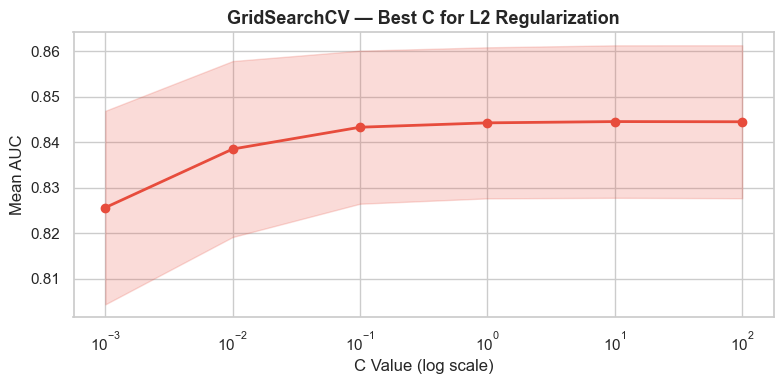

In [25]:
# ===== GridSearchCV — Best Hyperparameters =====
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=1000),
    param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_resampled, y_resampled)

print(f"✅ Best C     : {grid.best_params_['C']}")
print(f"✅ Best AUC   : {grid.best_score_:.3f}")

# Visualization
results_grid = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(param_grid['C'], results_grid['mean_test_score'],
         marker='o', color='#e74c3c', linewidth=2)
plt.fill_between(param_grid['C'],
                 results_grid['mean_test_score'] - results_grid['std_test_score'],
                 results_grid['mean_test_score'] + results_grid['std_test_score'],
                 alpha=0.2, color='#e74c3c')
plt.xscale('log')
plt.xlabel('C Value (log scale)', fontsize=12)
plt.ylabel('Mean AUC', fontsize=12)
plt.title('GridSearchCV — Best C for L2 Regularization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# ===== Random Forest + XGBoost =====
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models_v2 = {
    'Logistic Regression (Best C)': LogisticRegression(
        penalty='l2', C=grid.best_params_['C'], max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='logloss', verbosity=0),
}

results_v2 = {}

for name, model in models_v2.items():
    scores = cross_val_score(model, X_resampled, y_resampled,
                             cv=skf, scoring='roc_auc')
    results_v2[name] = scores
    print(f"{name}")
    print(f"  AUC per fold : {scores.round(3)}")
    print(f"  Mean AUC     : {scores.mean():.3f} ± {scores.std():.3f}\n")

Logistic Regression (Best C)
  AUC per fold : [0.843 0.875 0.824 0.841 0.839]
  Mean AUC     : 0.845 ± 0.017

Random Forest
  AUC per fold : [0.91  0.935 0.895 0.905 0.884]
  Mean AUC     : 0.906 ± 0.017

XGBoost
  AUC per fold : [0.884 0.904 0.855 0.889 0.87 ]
  Mean AUC     : 0.880 ± 0.016



In [27]:
# ===== Feature Engineering =====
df_fe = df.copy()

# New features
df_fe['Glucose_BMI']        = df_fe['Glucose'] * df_fe['BMI']
df_fe['Glucose_Age']        = df_fe['Glucose'] * df_fe['Age']
df_fe['BMI_Age']            = df_fe['BMI']     * df_fe['Age']
df_fe['Insulin_Glucose']    = df_fe['Insulin'] / (df_fe['Glucose'] + 1)

print("✅ New features added:")
print(df_fe[['Glucose_BMI', 'Glucose_Age', 'BMI_Age', 'Insulin_Glucose']].describe().round(2))

# Scale new data
X_fe = df_fe.drop('Outcome', axis=1)
y_fe = df_fe['Outcome']

scaler_fe = StandardScaler()
X_fe_scaled = scaler_fe.fit_transform(X_fe)

# SMOTE on new data
X_fe_res, y_fe_res = SMOTE(random_state=42).fit_resample(X_fe_scaled, y_fe)

# Cross Validation
model_fe = XGBClassifier(n_estimators=100, random_state=42,
                         eval_metric='logloss', verbosity=0)
scores_fe = cross_val_score(model_fe, X_fe_res, y_fe_res,
                            cv=skf, scoring='roc_auc')

print(f"\n✅ XGBoost + Feature Engineering")
print(f"  AUC per fold : {scores_fe.round(3)}")
print(f"  Mean AUC     : {scores_fe.mean():.3f} ± {scores_fe.std():.3f}")

✅ New features added:
       Glucose_BMI  Glucose_Age  BMI_Age  Insulin_Glucose
count       768.00       768.00   768.00           768.00
mean       3996.67      4139.38  1080.91             1.15
std        1469.66      2080.61   437.81             0.55
min        1100.00      1232.00   382.20             0.08
25%        2924.10      2608.50   744.80             0.83
50%        3750.15      3480.00   987.25             1.05
75%        4800.25      5130.75  1357.20             1.32
max       10692.00     12998.00  2697.00             4.80

✅ XGBoost + Feature Engineering
  AUC per fold : [0.881 0.919 0.874 0.894 0.863]
  Mean AUC     : 0.886 ± 0.019


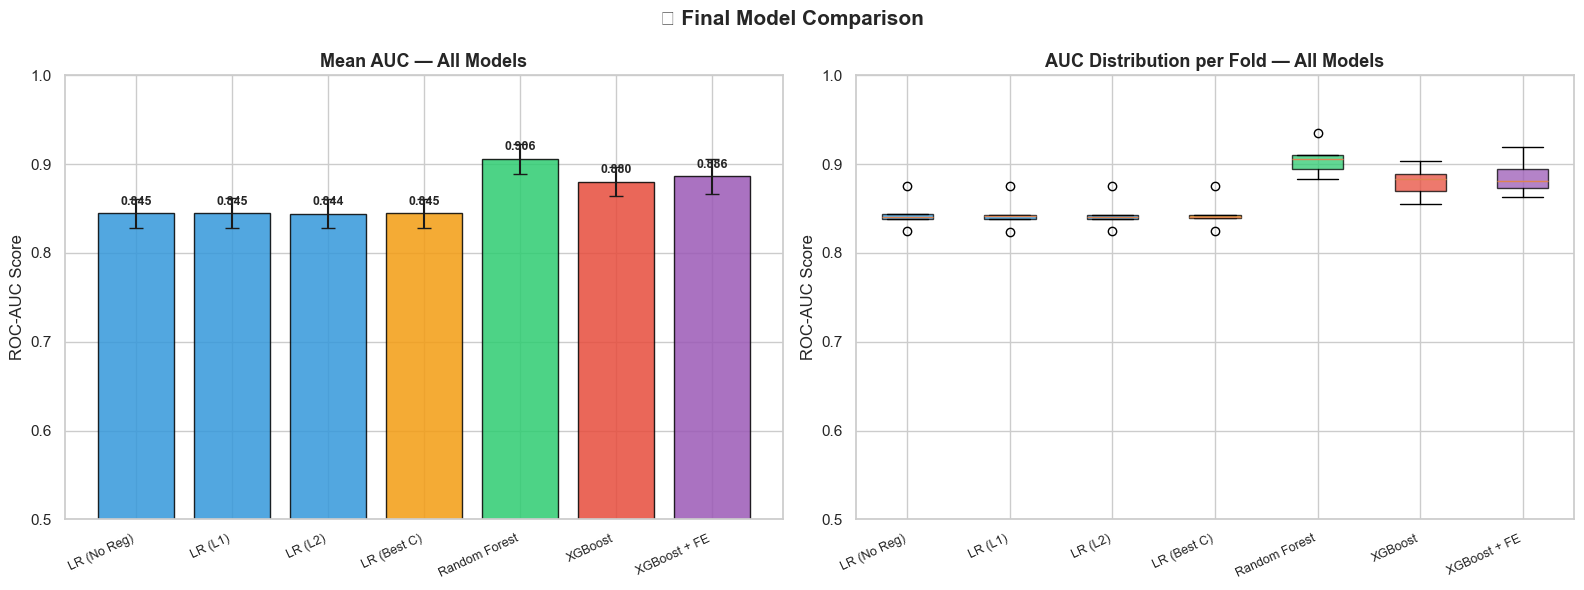


🏆 Final Leaderboard:
Model                       Mean AUC      Std
─────────────────────────────────────────────
Random Forest                  0.906    0.017
XGBoost + FE                   0.886    0.019
XGBoost                        0.880    0.016
LR (L1)                        0.845    0.017
LR (Best C)                    0.845    0.017
LR (No Reg)                    0.845    0.017
LR (L2)                        0.844    0.017


In [28]:
# ===== Final Comparison — All Models =====
all_results = {
    'LR (No Reg)'         : results['Logistic Regression (No Reg)'],
    'LR (L1)'             : results['Logistic Regression (L1)'],
    'LR (L2)'             : results['Logistic Regression (L2)'],
    'LR (Best C)'         : results_v2['Logistic Regression (Best C)'],
    'Random Forest'       : results_v2['Random Forest'],
    'XGBoost'             : results_v2['XGBoost'],
    'XGBoost + FE'        : scores_fe,
}

names_all  = list(all_results.keys())
means_all  = [all_results[m].mean() for m in names_all]
stds_all   = [all_results[m].std()  for m in names_all]
colors_all = ['#3498db','#3498db','#3498db','#f39c12','#2ecc71','#e74c3c','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar Plot
bars = axes[0].bar(names_all, means_all, yerr=stds_all,
                   capsize=5, color=colors_all, alpha=0.85, edgecolor='black')
axes[0].set_title('Mean AUC — All Models', fontsize=13, fontweight='bold')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticklabels(names_all, rotation=25, ha='right', fontsize=9)
for bar, mean in zip(bars, means_all):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')

# Box Plot
data_all = [all_results[m] for m in names_all]
bp = axes[1].boxplot(data_all, patch_artist=True, capwidths=0.4)
for patch, color in zip(bp['boxes'], colors_all):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('AUC Distribution per Fold — All Models',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_xticklabels(names_all, rotation=25, ha='right', fontsize=9)
axes[1].set_ylim(0.5, 1.0)

plt.suptitle('🏆 Final Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print Summary
print("\n🏆 Final Leaderboard:")
print(f"{'Model':<25} {'Mean AUC':>10} {'Std':>8}")
print("─" * 45)
for name, mean, std in sorted(zip(names_all, means_all, stds_all),
                               key=lambda x: x[1], reverse=True):
    print(f"{name:<25} {mean:>10.3f} {std:>8.3f}")

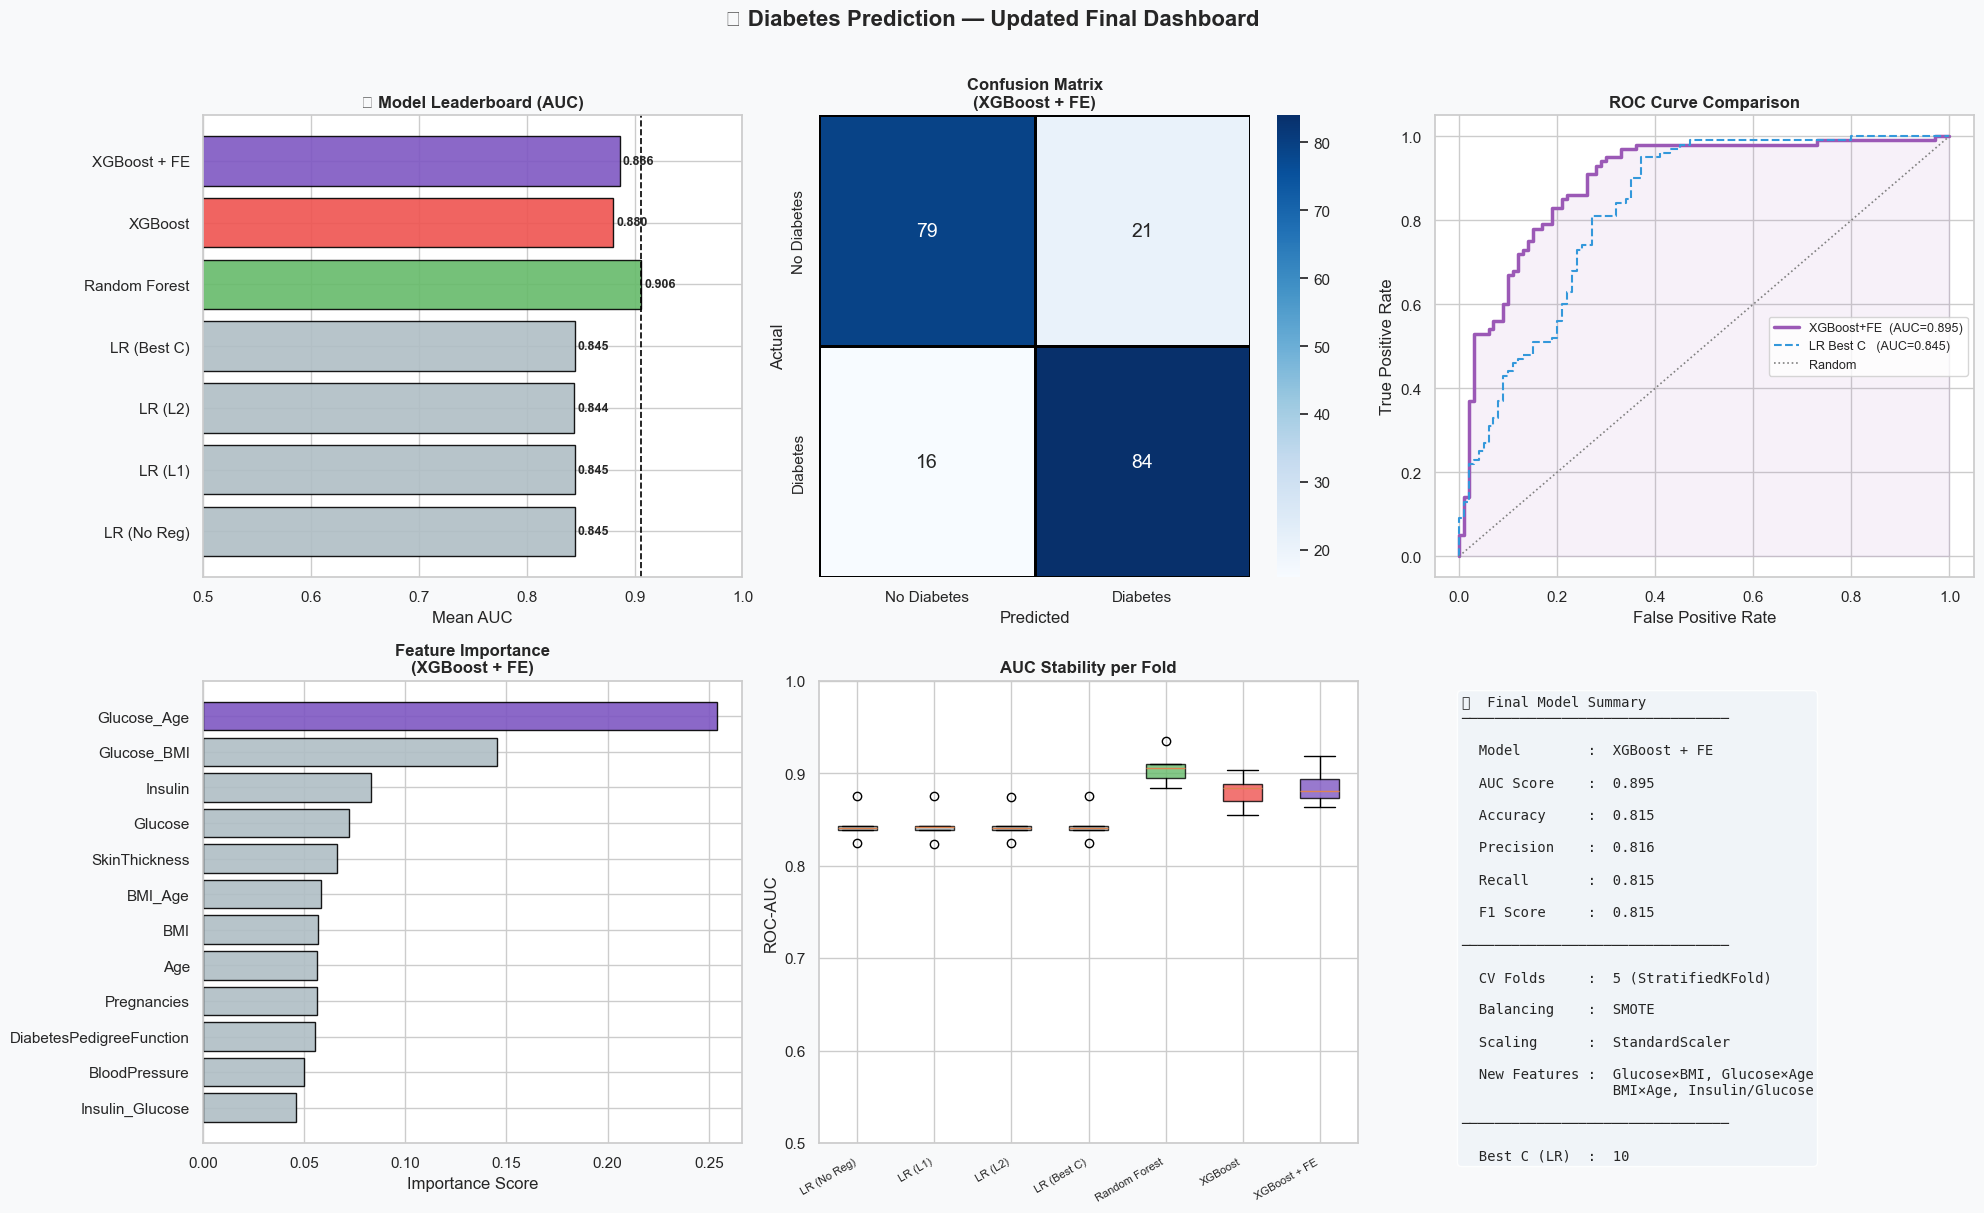

In [30]:
# ===== Updated Final Summary Dashboard =====

# Train best model (XGBoost + FE)
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_fe_res, y_fe_res, test_size=0.2,
    random_state=42, stratify=y_fe_res)

best_final = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss', verbosity=0)
best_final.fit(X_tr, y_tr)

y_pred_final = best_final.predict(X_te)
y_prob_final = best_final.predict_proba(X_te)[:, 1]

cm_final      = confusion_matrix(y_te, y_pred_final)
fpr_f, tpr_f, _ = roc_curve(y_te, y_prob_final)
auc_final     = roc_auc_score(y_te, y_prob_final)
report_final  = classification_report(y_te, y_pred_final,
                target_names=['No Diabetes', 'Diabetes'], output_dict=True)

# Feature importance from XGBoost
feat_names   = df_fe.drop('Outcome', axis=1).columns
imp_values   = best_final.feature_importances_
importance_fe = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': imp_values
}).sort_values('Importance', ascending=False)

# ─── Layout ───────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#f8f9fa')

# 1. Leaderboard
ax1 = fig.add_subplot(2, 3, 1)
names_all  = list(all_results.keys())
means_all  = [all_results[m].mean() for m in names_all]
colors_lb  = ['#b0bec5']*4 + ['#66bb6a', '#ef5350', '#7e57c2']
bars = ax1.barh(names_all, means_all, color=colors_lb,
                edgecolor='black', alpha=0.9)
ax1.axvline(x=max(means_all), color='black', linestyle='--', lw=1.2)
ax1.set_title('🏆 Model Leaderboard (AUC)', fontsize=12, fontweight='bold')
ax1.set_xlim(0.5, 1.0)
ax1.set_xlabel('Mean AUC')
for bar, val in zip(bars, means_all):
    ax1.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# 2. Confusion Matrix
ax2 = fig.add_subplot(2, 3, 2)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            linewidths=1, linecolor='black',
            annot_kws={"size": 14}, ax=ax2)
ax2.set_title('Confusion Matrix\n(XGBoost + FE)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

# 3. ROC Curve — All Models
ax3 = fig.add_subplot(2, 3, 3)
roc_colors = ['#3498db', '#f39c12', '#2ecc71', '#e74c3c', '#9b59b6']
roc_models = {
    'LR (L2)'        : (results['Logistic Regression (L2)'].mean(),   '#3498db'),
    'LR (Best C)'    : (results_v2['Logistic Regression (Best C)'].mean(), '#f39c12'),
    'Random Forest'  : (results_v2['Random Forest'].mean(),            '#2ecc71'),
    'XGBoost'        : (results_v2['XGBoost'].mean(),                  '#e74c3c'),
    'XGBoost + FE'   : (auc_final,                                     '#9b59b6'),
}
ax3.plot(fpr_f, tpr_f, color='#9b59b6', lw=2.5,
         label=f'XGBoost+FE  (AUC={auc_final:.3f})')
fpr_lr, tpr_lr, _ = roc_curve(y_te,
    LogisticRegression(penalty='l2', C=grid.best_params_['C'], max_iter=1000)
    .fit(X_tr, y_tr).predict_proba(X_te)[:, 1])
ax3.plot(fpr_lr, tpr_lr, color='#3498db', lw=1.5, linestyle='--',
         label=f'LR Best C   (AUC={results_v2["Logistic Regression (Best C)"].mean():.3f})')
ax3.plot([0,1],[0,1], 'gray', linestyle=':', lw=1.2, label='Random')
ax3.fill_between(fpr_f, tpr_f, alpha=0.08, color='#9b59b6')
ax3.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=9)

# 4. Feature Importance (XGBoost)
ax4 = fig.add_subplot(2, 3, 4)
colors_fi2 = ['#7e57c2' if i == 0 else '#b0bec5'
               for i in range(len(importance_fe))]
ax4.barh(importance_fe['Feature'], importance_fe['Importance'],
         color=colors_fi2, edgecolor='black', alpha=0.9)
ax4.set_title('Feature Importance\n(XGBoost + FE)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.invert_yaxis()

# 5. AUC Distribution Boxplot
ax5 = fig.add_subplot(2, 3, 5)
data_box   = [all_results[m] for m in names_all]
colors_box = ['#b0bec5']*4 + ['#66bb6a','#ef5350','#7e57c2']
bp = ax5.boxplot(data_box, patch_artist=True, capwidths=0.4)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax5.set_xticklabels(names_all, rotation=30, ha='right', fontsize=8)
ax5.set_title('AUC Stability per Fold', fontsize=12, fontweight='bold')
ax5.set_ylabel('ROC-AUC')
ax5.set_ylim(0.5, 1.0)

# 6. Final Metrics Summary
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
ax6.set_facecolor('#f0f4f8')
summary = (
    f"📊  Final Model Summary\n"
    f"{'─'*32}\n\n"
    f"  Model        :  XGBoost + FE\n\n"
    f"  AUC Score    :  {auc_final:.3f}\n\n"
    f"  Accuracy     :  {report_final['accuracy']:.3f}\n\n"
    f"  Precision    :  {report_final['weighted avg']['precision']:.3f}\n\n"
    f"  Recall       :  {report_final['weighted avg']['recall']:.3f}\n\n"
    f"  F1 Score     :  {report_final['weighted avg']['f1-score']:.3f}\n\n"
    f"{'─'*32}\n\n"
    f"  CV Folds     :  5 (StratifiedKFold)\n\n"
    f"  Balancing    :  SMOTE\n\n"
    f"  Scaling      :  StandardScaler\n\n"
    f"  New Features :  Glucose×BMI, Glucose×Age\n"
    f"                  BMI×Age, Insulin/Glucose\n\n"
    f"{'─'*32}\n\n"
    f"  Best C (LR)  :  {grid.best_params_['C']}"
)
ax6.text(0.05, 0.97, summary, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.9))

plt.suptitle('🏥 Diabetes Prediction — Updated Final Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

LR (No Reg)
  Accuracy per fold : [0.745 0.76  0.75  0.74  0.735]
  Mean Accuracy     : 0.746 ± 0.009

LR (L1)
  Accuracy per fold : [0.745 0.755 0.75  0.735 0.74 ]
  Mean Accuracy     : 0.745 ± 0.007

LR (L2)
  Accuracy per fold : [0.745 0.76  0.75  0.735 0.735]
  Mean Accuracy     : 0.745 ± 0.009

LR (Best C)
  Accuracy per fold : [0.745 0.76  0.75  0.74  0.735]
  Mean Accuracy     : 0.746 ± 0.009

Random Forest
  Accuracy per fold : [0.85  0.84  0.79  0.825 0.805]
  Mean Accuracy     : 0.822 ± 0.022

XGBoost
  Accuracy per fold : [0.8   0.81  0.765 0.84  0.815]
  Mean Accuracy     : 0.806 ± 0.024

XGBoost + FE
  Accuracy per fold : [0.79  0.815 0.81  0.83  0.775]
  Mean Accuracy     : 0.804 ± 0.019



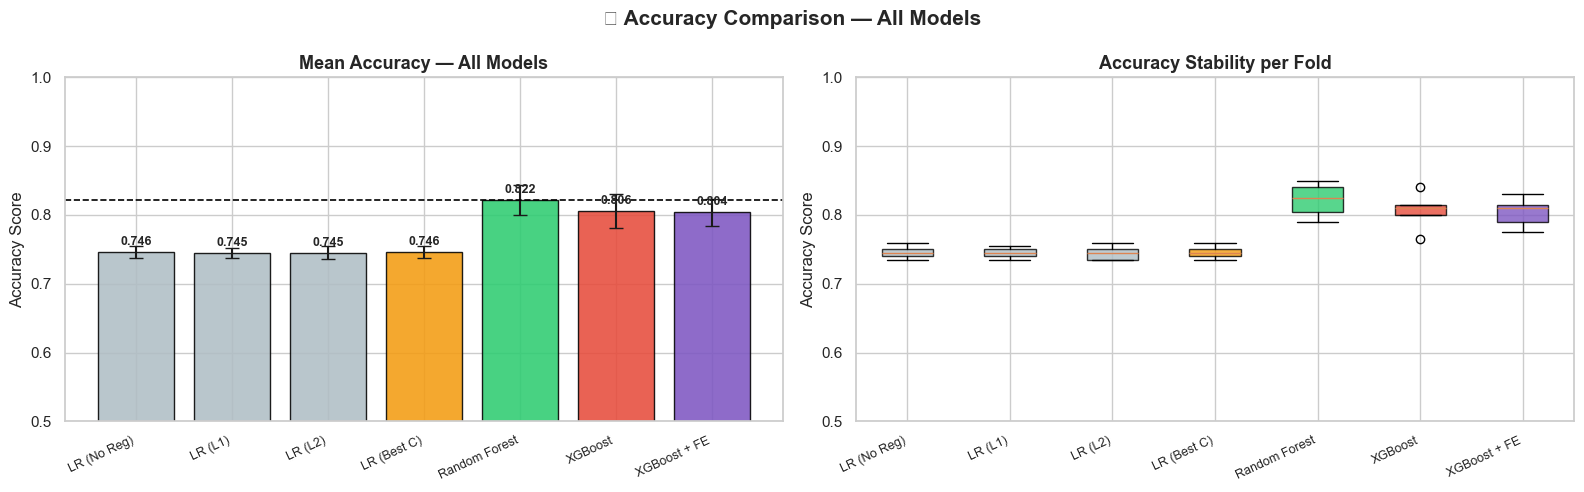


📊 Accuracy Leaderboard:
Model                  Mean Acc      Std
────────────────────────────────────────
Random Forest             0.822    0.022
XGBoost                   0.806    0.024
XGBoost + FE              0.804    0.019
LR (No Reg)               0.746    0.009
LR (Best C)               0.746    0.009
LR (L1)                   0.745    0.007
LR (L2)                   0.745    0.009


In [31]:
# ===== Accuracy Comparison — All Models =====
from sklearn.model_selection import cross_val_score

models_acc = {
    'LR (No Reg)'   : LogisticRegression(penalty=None, max_iter=1000),
    'LR (L1)'       : LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000),
    'LR (L2)'       : LogisticRegression(penalty='l2', C=1.0, max_iter=1000),
    'LR (Best C)'   : LogisticRegression(penalty='l2', C=grid.best_params_['C'], max_iter=1000),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'       : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'XGBoost + FE'  : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
}

acc_results = {}

for name, model in models_acc.items():
    X_used = X_fe_res if name == 'XGBoost + FE' else X_resampled
    y_used = y_fe_res if name == 'XGBoost + FE' else y_resampled

    scores = cross_val_score(model, X_used, y_used,
                             cv=skf, scoring='accuracy')
    acc_results[name] = scores
    print(f"{name}")
    print(f"  Accuracy per fold : {scores.round(3)}")
    print(f"  Mean Accuracy     : {scores.mean():.3f} ± {scores.std():.3f}\n")

# ─── Visualization ────────────────────────────────────────
names_acc = list(acc_results.keys())
means_acc = [acc_results[m].mean() for m in names_acc]
stds_acc  = [acc_results[m].std()  for m in names_acc]
colors_ac = ['#b0bec5','#b0bec5','#b0bec5','#f39c12','#2ecc71','#e74c3c','#7e57c2']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar Plot
bars = axes[0].bar(names_acc, means_acc, yerr=stds_acc,
                   capsize=5, color=colors_ac, alpha=0.88, edgecolor='black')
axes[0].set_title('Mean Accuracy — All Models', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(y=max(means_acc), color='black', linestyle='--', lw=1.2)
axes[0].set_xticklabels(names_acc, rotation=25, ha='right', fontsize=9)
for bar, mean in zip(bars, means_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')

# Box Plot
data_acc = [acc_results[m] for m in names_acc]
bp = axes[1].boxplot(data_acc, patch_artist=True, capwidths=0.4)
for patch, color in zip(bp['boxes'], colors_ac):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('Accuracy Stability per Fold', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy Score')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xticklabels(names_acc, rotation=25, ha='right', fontsize=9)

plt.suptitle('📊 Accuracy Comparison — All Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Leaderboard
print("\n📊 Accuracy Leaderboard:")
print(f"{'Model':<20} {'Mean Acc':>10} {'Std':>8}")
print("─" * 40)
for name, mean, std in sorted(zip(names_acc, means_acc, stds_acc),
                               key=lambda x: x[1], reverse=True):
    print(f"{name:<20} {mean:>10.3f} {std:>8.3f}")

In [33]:
# ===== Save All Models — Same Directory =====
import joblib
import numpy as np

# Save Models
joblib.dump(best_final,           "xgboost_fe.pkl")
joblib.dump(best_model,           "logistic_regression_l2.pkl")
joblib.dump(grid.best_estimator_, "logistic_regression_best_c.pkl")

# Save Scalers
joblib.dump(scaler,               "scaler.pkl")
joblib.dump(scaler_fe,            "scaler_fe.pkl")

# Save Resampled Data
np.save("X_resampled.npy",    X_resampled)
np.save("y_resampled.npy",    y_resampled)
np.save("X_fe_resampled.npy", X_fe_res)
np.save("y_fe_resampled.npy", y_fe_res)

print("✅ Saved successfully in the same directory!")
print("\n📁 Current Directory/")
print("  ├── xgboost_fe.pkl")
print("  ├── logistic_regression_l2.pkl")
print("  ├── logistic_regression_best_c.pkl")
print("  ├── scaler.pkl")
print("  ├── scaler_fe.pkl")
print("  ├── X_resampled.npy")
print("  ├── y_resampled.npy")
print("  ├── X_fe_resampled.npy")
print("  └── y_fe_resampled.npy")

✅ Saved successfully in the same directory!

📁 Current Directory/
  ├── xgboost_fe.pkl
  ├── logistic_regression_l2.pkl
  ├── logistic_regression_best_c.pkl
  ├── scaler.pkl
  ├── scaler_fe.pkl
  ├── X_resampled.npy
  ├── y_resampled.npy
  ├── X_fe_resampled.npy
  └── y_fe_resampled.npy
